<a href="https://colab.research.google.com/github/JotaBlanco/TheValley/blob/main/EDA/04-probabilidad/05_A___PROBLEMAS_Probabilidad_Resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Notebook por [Javier Blanco Cordero](https://www.linkedin.com/in/javier-blanco-cordero-71373656/).


# 01 - PROBABILIDAD














## 01.01 Probabilidad teórica

La probabilidad teórica de un suceso es el cociente entre el número de casos favorables y el número total de casos posibles, suponiendo que todos los resultados elementales son igualmente probables:
$$
P(A) = \frac{|A|}{|\Omega|}
$$

Se calcula a partir de un modelo ideal-
Ej. moneda perfecta:

$$
P(\text{cara}) = \frac{\text{casos favorables}}{\text{casos posibles}} = \frac{1}{2} = 0.5
$$

### 01.01.01 Ejemplo Moneda
Calcula las siguientes probabilidades para una moneda:

In [ ]:
## Definición del espacio muestral
casos_posibles = 2   # cara, cruz
casos_favorables = 1 # solo cara

P_cara = casos_favorables / casos_posibles
P_cara

0.5

**Probabilidad de obtener 3 caras consecutivas**
$$
P(\text{3 caras}) = P(\text{cara})^3 = \left(\frac{1}{2}\right)^3 = \frac{1}{8}
$$

In [ ]:
# Probabilidad de cara en una moneda perfecta
p_cara = 0.5

# Probabilidad de obtener 3 caras consecutivas
P_3_caras = p_cara ** 3
P_3_caras

0.125

**Probabilidad de obtener al menos una cruz en 3 lanzamientos**

$$
P(\geq 1\ \text{cruz}) = 1 - P(\text{ninguna cruz})
$$

Como no obtener ninguna cruz equivale a obtener tres caras seguidas:

$$
P(\geq 1\ \text{cruz}) = 1 - \left(\frac{1}{2}\right)^3
$$

In [ ]:
# Probabilidad de cara en una moneda perfecta
p_cara = 0.5

# Probabilidad de obtener al menos una cruz en 3 lanzamientos
P_al_menos_una_cruz = 1 - (p_cara ** 3)
P_al_menos_una_cruz

0.875

**Probabilidad de obtener k caras en n lanzamientos**

Sea X el número de caras obtenidas en n lanzamientos de una moneda perfecta.  
La probabilidad teórica de obtener exactamente k caras viene dada por:

$$
P(X = k) = \binom{n}{k} \left(\frac{1}{2}\right)^n
$$

Esta expresión define la distribución binomial para una moneda equilibrada.

In [ ]:
import math

def probabilidad_k_caras(n, k):
    """
    Calcula la probabilidad de obtener k caras
    en n lanzamientos de una moneda perfecta.
    """
    return math.comb(n, k) * (0.5 ** n)

# Ejemplo: exactamente 2 caras en 5 lanzamientos
probabilidad_k_caras(n=5, k=2)

0.3125

**Probabilidad de obtener al menos una racha de 3 caras consecutivas**

- Consideramos una moneda perfecta lanzada 10 veces.  
- Queremos calcular la probabilidad de que aparezca **al menos una racha de tres caras seguidas** en la secuencia.

Este evento no puede calcularse directamente con la distribución binomial, ya que depende del **orden** de los resultados y de **eventos solapados**.

Una forma analítica es calcular el complemento: Que **no aparezca ninguna racha de 3 caras consecutivas**. Esto equivale a contar todas las secuencias de 10 lanzamientos que **no contienen** el patrón `CCC`.

La probabilidad buscada es:

$$
P(\text{al menos una racha de 3 caras}) = 1 - \frac{\text{número de secuencias sin } CCC}{2^{10}}
$$

El conteo exacto puede hacerse mediante relaciones de recurrencia o cadenas de Markov, pero resulta algebraicamente complejo.

## 01.02 Probabilidad estadística
Se calcula a partir de observaciones reales, y puede diferir del valor teórico. Ej, tirar una moneda muchas veces.

### 01.02.01 Ejemplo Titanic
Calcula las siguientes probabilidades a partir del conjunto de datos `df_titanic` para un pasajero:

- probabilidad de morir
- probabilidad de ser mujer
- probabilidad de pertenecer a cada clase (Pclass)
- probabilidad de tener menos de 18 años
- probabilidad de haber pagado más de 50 dólares por el billete

In [ ]:
# Url archivo raw
url = 'https://raw.githubusercontent.com/JotaBlanco/TheValley/refs/heads/main/Data/titanic.csv'

# Importa csv
df_titanic = pd.read_csv(url)

# Visualización primeras filas
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Probabilidad de fallecer**



La fórmula será: P(Falleció) = (Número de pasajeros que murieron) / (Número total de pasajeros).


In [ ]:
filtro_evento = df_titanic['Survived'] == 0

num_fallecidos = filtro_evento.sum()
total_pasajeros = len(df_titanic)
prob_fallecer = num_fallecidos / total_pasajeros

print(f"Númbero de fallecidos: {num_fallecidos}")
print(f"Total pasajeros: {total_pasajeros}")
print(f"Probabilidad de que un pasajero fallezca: {prob_fallecer:.4f}")

Númbero de fallecidos: 549
Total pasajeros: 891
Probabilidad de que un pasajero fallezca: 0.6162


**Probabilidad de ser mujer**

La fórmula será: P(Mujer) = (Número de pasajeros mujeres) / (Número total de pasajeros).


In [ ]:
filtro_evento = df_titanic['Sex'] == 'female'
num_mujeres = filtro_evento.sum()
prob_mujer = num_mujeres / total_pasajeros

print(f"Número de mujeres: {num_mujeres}")
print(f"Total de pasajeros: {total_pasajeros}")
print(f"Probabilidad de que un pasajero sea mujer: {prob_mujer:.4f}")

Número de mujeres: 314
Total de pasajeros: 891
Probabilidad de que un pasajero sea mujer: 0.3524


**Probabilidad de clase**

La fórmula de la probabilidad de pertenecer a cada clase: P(clase X) = (Número de pasajeros en clase X) / (Número total de pasajeros).

In [ ]:
clases = df_titanic['Pclass'].sort_values().unique()
clases

array([1, 2, 3])

In [ ]:
print("Probabilidad de pertenecer a cada Pclass:")
for clase_i in clases:
    filtro_evento = df_titanic['Pclass'] == clase_i
    count = filtro_evento.sum()
    prob_pclass = count / total_pasajeros
    print(f"Pclass {clase_i}: {prob_pclass:.4f} (Número de pasajeros: {count})")

Probabilidad de pertenecer a cada Pclass:
Pclass 1: 0.2424 (Número de pasajeros: 216)
Pclass 2: 0.2065 (Número de pasajeros: 184)
Pclass 3: 0.5511 (Número de pasajeros: 491)


**Probabilidad de edad menor a 18**

La fórmula de la probabilidad de que un pasajero tenga menos de 10 años es: P(Edad<18) = (Número de pasajeros menores de 18) / (Número total de pasajeros).

In [ ]:
filtro_evento = df_titanic['Age'] < 18
num_menores_18 = filtro_evento.sum()
prob_menores_18 = num_menores_18 / total_pasajeros

print(f"Número de pasajeros menores de 18 años: {num_menores_18}")
print(f"Total de pasajeros: {total_pasajeros}")
print(f"Probabilidad de que un pasajero tenga menos de 18 años: {prob_menores_18:.4f}")

Número de pasajeros menores de 18 años: 113
Total de pasajeros: 891
Probabilidad de que un pasajero tenga menos de 18 años: 0.1268


## 01.03 - Probabilidad Simulada
Es un híbrido donde creamos un entorno controlado por ordenador para repetir un experimento miles de veces. Nos permite "crear" nuestros propios datos cuando los reales son escasos o el problema es demasiado complejo para la matemática ideal.

### 01.03.01 - Ejemplo Moneda

In [ ]:
tiradas = 10
pd.DataFrame(
    [np.random.choice([1,0], tiradas)],
    columns=[f"Ronda {i}" for i in range(tiradas)]
    )

,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,Ronda 8,Ronda 9
0,1,1,1,1,0,1,0,0,0,0


In [ ]:
def simular_lanzamiento_moneda(tiradas):
    df_i = pd.DataFrame(
        [np.random.choice([1,0], tiradas)],
        columns=[f"Ronda {i}" for i in range(tiradas)]
        )
    return df_i

In [ ]:
def escenario_simulacion(num_simulaciones, funcion_sim):
    df_sim = pd.DataFrame()
    for _ in range(num_simulaciones):
        df_sim_i = funcion_sim()
        df_sim = pd.concat([df_sim, df_sim_i], ignore_index=True)
    return df_sim

In [ ]:
df_1 = escenario_simulacion(
    num_simulaciones = 10000,
    funcion_sim = lambda: simular_lanzamiento_moneda(tiradas=1))
df_1

,Ronda 0
0,0
1,1
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,1


In [ ]:
(df_1["Ronda 0"] == 1).sum()/10000

np.float64(0.4935)

### 01.03.02 Ejercicios Moneda

#### Probabilidad de obtener 3 caras consecutivas

In [ ]:
# Simulación para Probabilidad de obtener 3 caras consecutivas
df_sim_3 = escenario_simulacion(
    num_simulaciones=100000,
    funcion_sim=lambda: simular_lanzamiento_moneda(tiradas=3))

df_sim_3

,Ronda 0,Ronda 1,Ronda 2
0,1,0,0
1,0,1,0
2,0,1,1
3,1,0,1
4,1,0,0
...,...,...,...
99995,0,0,0
99996,0,0,1
99997,0,0,1
99998,1,1,1


In [ ]:
(df_sim_3.sum(axis=1)==3).sum()/100000

np.float64(1.2462)

#### Probabilidad obtener al menos una cruz en 3 lanzamientos

In [ ]:
(df_sim_3.sum(axis=1)<=2).sum()/100000

np.float64(0.87538)

#### Probabilidad racha al menos 3 caras seguidas en 10 lanzamientos

In [ ]:
# Simulación para Probabilidad de obtener 3 caras consecutivas
df_sim_10 = escenario_simulacion(
    num_simulaciones=10000,
    funcion_sim=lambda: simular_lanzamiento_moneda(tiradas=10))

df_sim_10

,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,Ronda 8,Ronda 9
0,0,0,1,0,1,1,0,0,0,0
1,1,1,1,1,1,1,0,0,0,0
2,1,0,1,0,0,0,1,0,1,1
3,1,0,0,1,0,1,1,1,1,0
4,1,1,1,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,0,1,0,0,1,0,0,1,0,1
9996,0,0,1,1,0,1,0,1,1,1
9997,1,1,0,1,1,0,1,0,1,1
9998,0,0,1,1,1,0,0,0,0,0


In [ ]:
df_sim_10.astype(str).sum(axis=1).str.contains('111').sum()/10000

np.float64(0.5041)

# 02 - Probabilidad condicionada

La probabilidad condicionada de un suceso \(A\) dado que ha ocurrido un suceso \(B\) es el cociente entre la probabilidad de que ocurran ambos sucesos y la probabilidad de que ocurra \(B\), siempre que \(P(B) > 0\):

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$


## 02.01 Ejemplo teórico: El Lanzamiento de un Dado

Para ilustrar la fórmula anterior, utilizaremos el ejemplo del dado de 6 caras:

* **Suceso $B$ (Condición):** Sabemos que el resultado ha sido un número **par**. Los resultados posibles son $\{2, 4, 6\}$, por lo que $P(B) = \frac{3}{6} = 0.5$.
* **Suceso $A$:** Queremos saber la probabilidad de que el resultado sea un **4**.
* **Suceso $A \cap B$:** Es la probabilidad de que el número sea 4 **y** sea par al mismo tiempo. Como el 4 es par, solo hay 1 caso favorable $\{4\}$, por lo que $P(A \cap B) = \frac{1}{6}$.

**Aplicando la fórmula:**

$$P(4 \mid \text{par}) = \frac{P(4 \cap \text{par})}{P(\text{par})} = \frac{1/6}{3/6}$$

Al simplificar, los denominadores (6) se eliminan y obtenemos:

$$P(4 \mid \text{par}) = \frac{1}{3} \approx 33.3\%$$

In [ ]:
# Resolución del ejemplo

# 1. Definimos el espacio muestral (un dado de 6 caras)
dado = {1, 2, 3, 4, 5, 6}

# 2. Definimos los eventos
evento_par = {2, 4, 6}
evento_cuatro = {4}

In [ ]:
# 3. Calculamos la intersección (A ∩ B)
interseccion = evento_cuatro.intersection(evento_par)
interseccion

{4}

In [ ]:
# 4. Calculamos las probabilidades
p_b = len(evento_par) / len(dado)
p_a_inter_b = len(interseccion) / len(dado)

# 5. Aplicamos la fórmula de probabilidad condicionada
p_condicionada = p_a_inter_b / p_b

In [ ]:
print(f"Probabilidad par, P(B): {p_b:.2f}")
print(f"Probabilidad 4 y par, P(A ∩ B): {p_a_inter_b:.2f}")
print(f"Probabilidad de que sea 4 DADO que es par, P(A|B): {p_condicionada:.2f}")

Probabilidad par, P(B): 0.50
Probabilidad 4 y par, P(A ∩ B): 0.17
Probabilidad de que sea 4 DADO que es par, P(A|B): 0.33


## 02.02 Ejemplo estadístico: Titanic
### 02.02.01 Probabilidad de ser mujer entre menores de 18
La fórmula será: P(Mujer | Edad < 18) = (Número de mujeres menores de 18) / (Número total de pasajeros menores de 18).

In [ ]:
print("Probabilidad de ser mujer entre menores de 18:")

filtro_mujeres = df_titanic['Sex'] == 'female'
prob_mujer = filtro_mujeres.sum()/len(df_titanic)
print(f"P(Mujer): {prob_mujer:.4f}")

filtro_menores_18 = df_titanic['Age'] < 18

num_mujeres_menores_18 = (filtro_menores_18 & filtro_mujeres).sum()
total_menores_18 = filtro_menores_18.sum()

prob_mujer_dado_menor_18 = num_mujeres_menores_18 / total_menores_18
print(f"P(Mujer | Edad < 18): {prob_mujer_dado_menor_18:.4f} (Mujeres menores de 18: {num_mujeres_menores_18}, Total menores de 18: {total_menores_18})")

Probabilidad de ser mujer entre menores de 18:
P(Mujer): 0.3524
P(Mujer | Edad < 18): 0.4867 (Mujeres menores de 18: 55, Total menores de 18: 113)


### 02.02.02 Probabilidad de fallecer según género
La fórmula será: P(Falleció | Sexo) = (Número de pasajeros que fallecieron y eran de un sexo dado) / (Número total de pasajeros de ese sexo).

In [ ]:
sexos = df_titanic['Sex'].unique()

print("Probabilidad de fallecer según el género:")

filtro_fallecidos = df_titanic['Survived'] == 0
prob_fallecer = filtro_fallecidos.sum()/len(df_titanic)
print(f"P(Fallecer): {prob_fallecer:.4f}")

for sexo in sexos:
    filtro_sexo = df_titanic['Sex'] == sexo

    num_fallecidos_sexo = (filtro_sexo & filtro_fallecidos).sum()
    total_sexo = filtro_sexo.sum()

    prob_fallecer_dado_sexo = num_fallecidos_sexo / total_sexo
    print(f"P(Fallecer | {sexo}): {prob_fallecer_dado_sexo:.4f} (Fallecidos {sexo}: {num_fallecidos_sexo}, Total {sexo}: {total_sexo})")

Probabilidad de fallecer según el género:
P(Fallecer): 0.6162
P(Fallecer | male): 0.8111 (Fallecidos male: 468, Total male: 577)
P(Fallecer | female): 0.2580 (Fallecidos female: 81, Total female: 314)


### 02.02.03 Probabilidad de fallecer según la clase
La fórmula será: P(Falleció | Pclass) = (Número de pasajeros que fallecieron y eran de una Pclass dada) / (Número total de pasajeros de esa Pclass).

In [ ]:
clases_p = df_titanic['Pclass'].sort_values().unique()

print("Probabilidad de fallecer según la clase (Pclass):")

filtro_fallecidos = df_titanic['Survived'] == 0
prob_fallecer = filtro_fallecidos.sum()/len(df_titanic)
print(f"P(Fallecer): {prob_fallecer:.4f}")

for clase_i in clases_p:
    filtro_clase = df_titanic['Pclass'] == clase_i

    num_fallecidos_clase = (filtro_clase & filtro_fallecidos).sum()
    total_clase = filtro_clase.sum()

    prob_fallecer_dado_clase = num_fallecidos_clase / total_clase
    print(f"P(Fallecer | Pclass {clase_i}): {prob_fallecer_dado_clase:.4f} (Fallecidos Pclass {clase_i}: {num_fallecidos_clase}, Total Pclass {clase_i}: {total_clase})")

Probabilidad de fallecer según la clase (Pclass):
P(Fallecer): 0.6162
P(Fallecer | Pclass 1): 0.3704 (Fallecidos Pclass 1: 80, Total Pclass 1: 216)
P(Fallecer | Pclass 2): 0.5272 (Fallecidos Pclass 2: 97, Total Pclass 2: 184)
P(Fallecer | Pclass 3): 0.7576 (Fallecidos Pclass 3: 372, Total Pclass 3: 491)


### 02.02.04 Probabilidad de fallecer siendo menor de 18
La fórmula será: P(Falleció | Edad < 18) = (Número de pasajeros menores de 18 que fallecieron) / (Número total de pasajeros menores de 18).

In [ ]:
print("Probabilidad de fallecer siendo menor de 18:")

filtro_fallecidos = df_titanic['Survived'] == 0
prob_fallecer = filtro_fallecidos.sum()/len(df_titanic)
print(f"P(Fallecer): {prob_fallecer:.4f}")

filtro_menores_18 = df_titanic['Age'] < 18

num_fallecidos_menores_18 = (filtro_menores_18 & filtro_fallecidos).sum()
total_menores_18_conocida = filtro_menores_18.sum()

prob_fallecer_dado_menor_18 = num_fallecidos_menores_18 / total_menores_18_conocida
print(f"P(Fallecer | Edad < 18): {prob_fallecer_dado_menor_18:.4f} (Fallecidos menores de 18: {num_fallecidos_menores_18}, Total menores de 18: {total_menores_18_conocida})")

Probabilidad de fallecer siendo menor de 18:
P(Fallecer): 0.6162
P(Fallecer | Edad < 18): 0.4602 (Fallecidos menores de 18: 52, Total menores de 18: 113)


## 02.03 Ejemplo simulación: Titanic
Veamos cómo el uso de la simulación nos puede dar información muy útil, también con datasets, como en el caso del Titanic.

### 02.03.01 - Validar hipótesis
Cuando queremos estudiar una hipotesis, uno de los aspectos clave es entender la certidumbre: cómo de seguros estamos? podría una correlación ser fruto del azar?
Vamos a validar dos hipotesis:


*   Ser menor de edad influye en la mortalidad
*   El género del pasajero influye en la mortalidad
*   El puerto desde el que se embarcó influye en la mortalidad


In [ ]:
df_titanic["Survived"].mean()

np.float64(0.3838383838383838)

In [ ]:
filtro_menor = df_titanic['Age'] < 18
df_titanic.loc[filtro_menor,"Survived"].mean()

np.float64(0.5398230088495575)

In [ ]:
df_titanic.groupby("Embarked")["Survived"].describe()

,count,mean,std,min,25%,50%,75%,max
Embarked,,,,,,,,
C,168.0,0.553571,0.498608,0.0,0.0,1.0,1.0,1.0
Q,77.0,0.389610,0.490860,0.0,0.0,0.0,1.0,1.0
S,644.0,0.336957,0.473037,0.0,0.0,0.0,1.0,1.0


#### PASO 1: Crear variable

In [ ]:
df_titanic['is_child'] = df_titanic['Age'] < 18

In [ ]:
df_titanic["Survived"].mean()

np.float64(0.3838383838383838)

In [ ]:
df_titanic.loc[df_titanic["is_child"]==1,"Survived"].mean()

np.float64(0.5398230088495575)

#### PASO 2: Calcular diferencia supervivencia


In [ ]:
survival_rate_child = df_titanic[df_titanic['is_child'] == True]['Survived'].mean()
survival_rate_adult = df_titanic[df_titanic['is_child'] == False]['Survived'].mean()
diff_obs = survival_rate_child - survival_rate_adult

print(f"Survival rate for children (Age < 18): {survival_rate_child:.4f}")
print(f"Survival rate for adults (Age >= 18): {survival_rate_adult:.4f}")
print(f"Observed difference in survival rates: {diff_obs:.4f}")

Survival rate for children (Age < 18): 0.5398
Survival rate for adults (Age >= 18): 0.3612
Observed difference in survival rates: 0.1786


In [ ]:
def funcion_obtener_media(df, col_vector, target_name):
    df["groupbycol"] = col_vector
    stats = df.groupby("groupbycol")[target_name].mean()
    data = {}
    for g, v in stats.items():
        data[f"{target_name}_mean_{g}"] = v
    return pd.DataFrame([data])

In [ ]:
funcion_obtener_media(
    df = df_titanic,
    col_vector = df_titanic['is_child'],
    target_name = 'Survived')

,Survived_mean_False,Survived_mean_True
0,0.361183,0.539823


#### PASO 3: Función de shuffling
Crea una función que tome el dataset, mezcle aleatoriamente la etiqueta 'Edad < 18' y calcule la diferencia en la tasa de supervivencia para esta nueva asignación aleatoria. La función debe devolver esta diferencia.


In [ ]:
df_titanic['is_child'].sample(frac=1).reset_index(drop=True)

,is_child
0,True
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,True


In [ ]:
funcion_obtener_media(
    df = df_titanic,
    col_vector = df_titanic['is_child'].sample(frac=1).reset_index(drop=True),
    target_name = 'Survived')


,Survived_mean_False,Survived_mean_True
0,0.383033,0.389381


#### PASO 4: Simulación
Utiliza la función `escenario_simulacion` para ejecutar 10,000 simulaciones de shuffling, recolectando las diferencias en las tasas de supervivencia para cada simulación. Esto generará una distribución de las diferencias esperadas por azar.


In [ ]:
num_simulaciones = 10000
sim_titanic_1 = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: funcion_obtener_media(
                          df = df_titanic,
                          col_vector = df_titanic['is_child'].sample(frac=1).reset_index(drop=True),
                          target_name = 'Survived')
)
sim_titanic_1.head()

,Survived_mean_False,Survived_mean_True
0,0.394602,0.309735
1,0.386889,0.362832
2,0.385604,0.371681
3,0.379177,0.415929
4,0.377892,0.424779


#### PASO 5: Distribución
Ahora podemos observar la distribución de las diferencias.



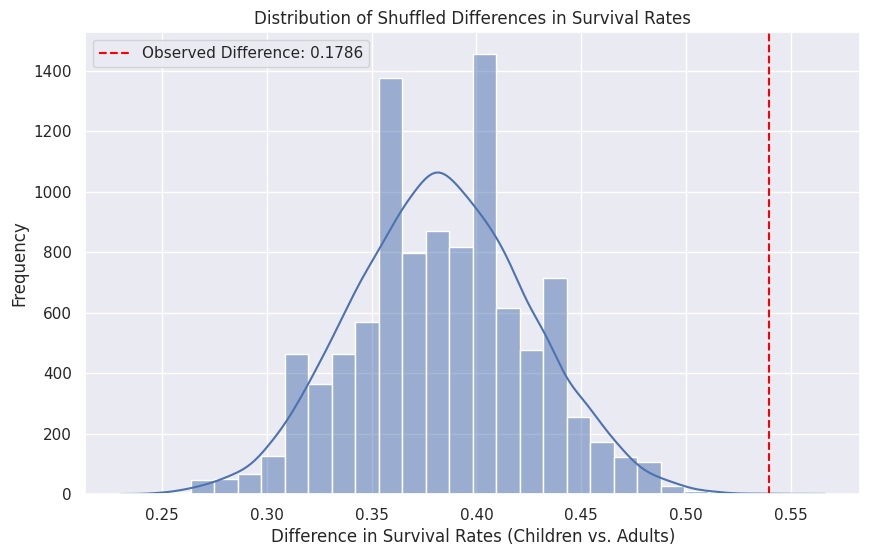

In [ ]:
# Media
plt.figure(figsize=(10, 6))
sns.histplot(sim_titanic_1["Survived_mean_True"], kde=True, bins=30)
valor_real = df_titanic[df_titanic['is_child'] == True]['Survived'].mean()
plt.axvline(valor_real, color='red', linestyle='--', label=f'Observed Difference: {diff_obs:.4f}')
plt.title('Distribution of Shuffled Differences in Survival Rates')
plt.xlabel('Difference in Survival Rates (Children vs. Adults)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

#### PASO 6: p-value
Calcula el p-valor, que es la proporción de simulaciones de shuffling en las que la diferencia aleatoria fue igual o más extrema que la diferencia observada. Un p-valor bajo indicará que la asociación observada es poco probable que se deba al azar, lo que aumenta la confianza en que la asociación es real.


In [ ]:
np.sum(np.abs(sim_titanic_1["Survived_mean_True"]) >= abs(valor_real))/10000

np.float64(0.0004)

### 02.03.02 - Ejercicio
Ver la certidumbre de que el puerto de embarque influye sobre la probabilidad de fallecer.

In [ ]:
df_titanic.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


In [ ]:
valor_real_C = df_titanic.loc[df_titanic["Embarked"]=="C","Survived"].mean()
print(valor_real_C)
valor_real_Q = df_titanic.loc[df_titanic["Embarked"]=="Q","Survived"].mean()
print(valor_real_Q)
valor_real_S = df_titanic.loc[df_titanic["Embarked"]=="S","Survived"].mean()
print(valor_real_S)

0.5535714285714286
0.38961038961038963
0.33695652173913043


In [ ]:
funcion_obtener_media(
    df = df_titanic,
    col_vector = df_titanic['Embarked'],
    target_name = 'Survived')

,Survived_mean_C,Survived_mean_Q,Survived_mean_S
0,0.553571,0.38961,0.336957


In [ ]:
funcion_obtener_media(
    df = df_titanic,
    col_vector = df_titanic['Embarked'].sample(frac=1).reset_index(drop=True),
    target_name = 'Survived')

,Survived_mean_C,Survived_mean_Q,Survived_mean_S
0,0.315476,0.376623,0.403727


In [ ]:
num_simulaciones = 10000
sim_puerto = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: funcion_obtener_media(
                            df = df_titanic,
                            col_vector = df_titanic['Embarked'].sample(frac=1).reset_index(drop=True),
                            target_name = 'Survived')
)
sim_puerto.head()

,Survived_mean_C,Survived_mean_Q,Survived_mean_S
0,0.369048,0.246753,0.405280
1,0.410714,0.415584,0.372671
2,0.363095,0.389610,0.389752
3,0.452381,0.402597,0.361801
4,0.398810,0.363636,0.381988


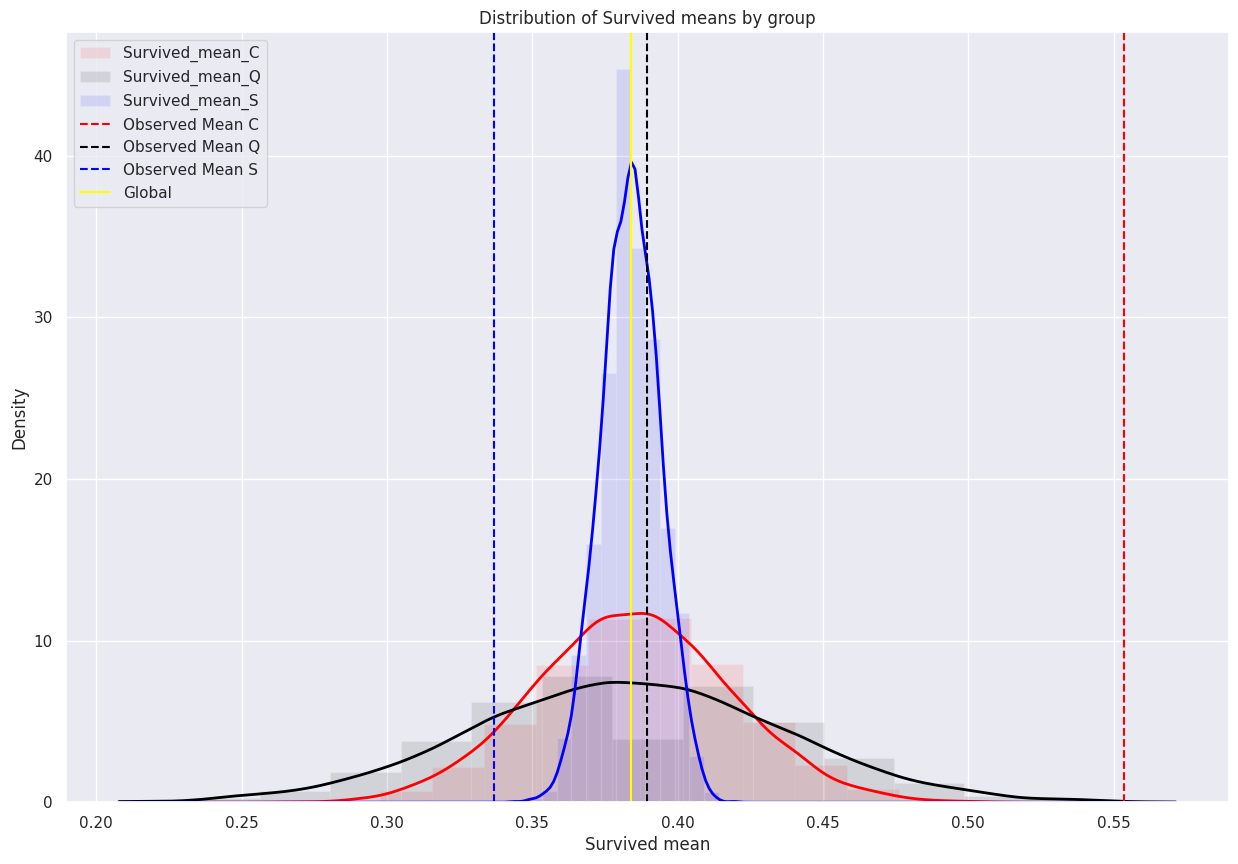

In [ ]:
from scipy.stats import gaussian_kde

colors = {
    "Survived_mean_C": "red",
    "Survived_mean_Q": "black",
    "Survived_mean_S": "blue"
}

plt.figure(figsize=(15, 10), facecolor="white")
x_grid = np.linspace(sim_puerto.min().min(), sim_puerto.max().max(), 300)

for col, color in colors.items():
    values = sim_puerto[col].dropna()

    # Histogram
    plt.hist(values, bins=15, density=True, alpha=0.1, color=color, label=col)

    # KDE
    kde = gaussian_kde(values)
    plt.plot(x_grid, kde(x_grid), color=color, linewidth=2)


plt.axvline(valor_real_C, color='red', linestyle='--', label=f'Observed Mean C')
plt.axvline(valor_real_Q, color='black', linestyle='--', label=f'Observed Mean Q')
plt.axvline(valor_real_S, color='blue', linestyle='--', label=f'Observed Mean S')
plt.axvline(df_titanic["Survived"].mean(), color='yellow', linestyle='-', label=f'Global')
plt.xlabel("Survived mean")
plt.ylabel("Density")
plt.title("Distribution of Survived means by group")
plt.legend()
plt.show()

In [ ]:
df_titanic.groupby("Embarked")["Survived"].describe()

,count,mean,std,min,25%,50%,75%,max
Embarked,,,,,,,,
C,168.0,0.553571,0.498608,0.0,0.0,1.0,1.0,1.0
Q,77.0,0.389610,0.490860,0.0,0.0,0.0,1.0,1.0
S,644.0,0.336957,0.473037,0.0,0.0,0.0,1.0,1.0


In [ ]:
diffs_reales = {
    "C": valor_real_C - df_titanic["Survived"].mean(),
    "Q": valor_real_Q - df_titanic["Survived"].mean(),
    "S": valor_real_S - df_titanic["Survived"].mean()
}
print(diffs_reales)

{'C': np.float64(0.1697330447330448), 'Q': np.float64(0.005772005772005817), 'S': np.float64(-0.04688186209925338)}


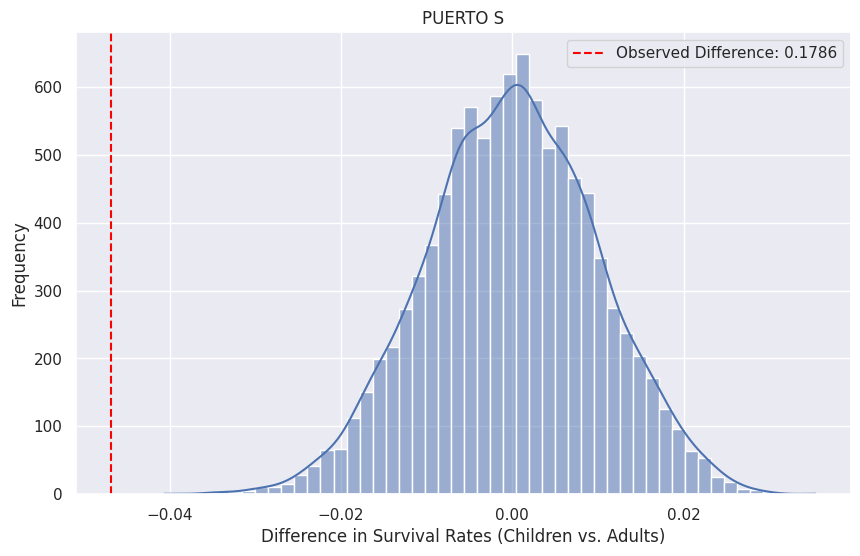

P-Value: 0.0


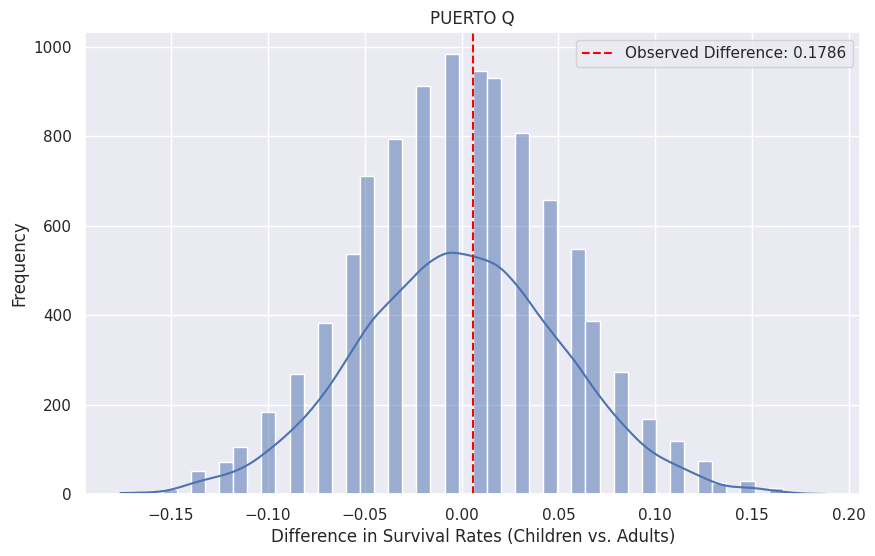

P-Value: 1.0


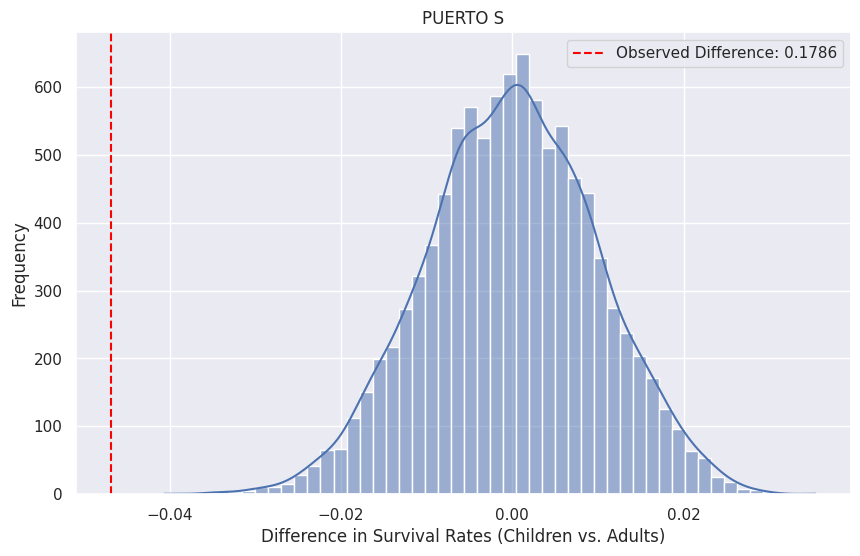

P-Value: 0.0


In [ ]:
# PUERTO S
for puerto_i in ["S","Q","S"]:
    filter = df_titanic["Embarked"] == puerto_i
    diff_real = diffs_reales[puerto_i]
    diffs_simuladas = (sim_puerto[f"Survived_mean_{puerto_i}"] - df_titanic["Survived"].mean()).values

    plt.figure(figsize=(10, 6))
    sns.histplot(diffs_simuladas, kde=True, bins=50)
    plt.axvline(diff_real, color='red', linestyle='--', label=f'Observed Difference: {diff_obs:.4f}')
    plt.title(f"PUERTO {puerto_i}")
    plt.xlabel('Difference in Survival Rates (Children vs. Adults)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

    p_value = np.mean(np.abs(diffs_simuladas) >= np.abs(diff_real))
    print("P-Value:", p_value)

# PROBLEMA 1: Ruleta RUSA
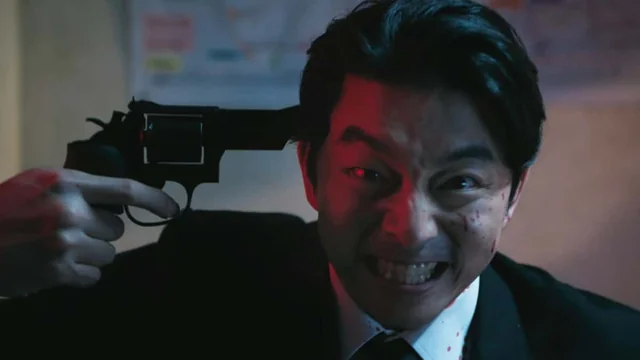

Mira este vídeo un par de veces:
https://www.youtube.com/shorts/fSE360qk1n4


*   1 bala, 6 huecos en la recámara
*   Ronda 1 | Jugador dispara: no hay bala
*   Ronda 2 | Reclutador dispara: no hay bala
*   Ronda 3 | Jugador dispara: no hay bala
*   Ronda 4 | Reclutador dispara: no hay bala
*   Ronda 5 | Jugador dispara: no hay bala
*   Ronda 6 | Reclutador dispara: MUERE (hay bala)


## Tarea: Realiza un análisis probabilístico de un escenario de ruleta rusa.

Establece las variables iniciales (número total de agujeros, número de balas y número de huecos vacíos) y calcula las probabilidades de:
- que la bala salte en cada ronda
- fallecer en cada ronda para los participantes una vez han llegado a esta (probabilidad condicional)
- que cada uno fallezca en cualquier momento del juego (probabilidad acumulada)
- que la bala sea el último disparo

### 01 - Probabilidad Teórica


In [ ]:
# Probabilidad bala salte en cada ronda
1/6

0.16666666666666666

In [ ]:
# Probabilidad Condicionada de Morir en Cada Disparo

num_agujeros = 6
num_balas = 1

for i in range(1, num_agujeros+1): # turnos
    jugador = "Protagonista" if i % 2 != 0 else "Reclutador"

    if num_agujeros > 0:
        prob_morir_condicional = num_balas / num_agujeros
        print(f"Turno {i} ({jugador}):")
        print(f"  Probabilidad de morir: {prob_morir_condicional:.4f} ({num_balas} bala(s) / {num_agujeros} agujero(s))")

    num_agujeros -= 1



Turno 1 (Protagonista):
  Probabilidad de morir: 0.1667 (1 bala(s) / 6 agujero(s))
Turno 2 (Reclutador):
  Probabilidad de morir: 0.2000 (1 bala(s) / 5 agujero(s))
Turno 3 (Protagonista):
  Probabilidad de morir: 0.2500 (1 bala(s) / 4 agujero(s))
Turno 4 (Reclutador):
  Probabilidad de morir: 0.3333 (1 bala(s) / 3 agujero(s))
Turno 5 (Protagonista):
  Probabilidad de morir: 0.5000 (1 bala(s) / 2 agujero(s))
Turno 6 (Reclutador):
  Probabilidad de morir: 1.0000 (1 bala(s) / 1 agujero(s))


In [ ]:
# Probabilidad cada uno fallezca en cualquier momento
fallece_1 = {1, 3, 5}
fallece_2 = {2, 4, 6}
rondas = {1, 2, 3, 4, 5, 6}

# Para calcular la proporción, usa len() para obtener el número de elementos en el set
prob_fallece_1 = len(fallece_1) / len(rondas)
prob_fallece_2 = len(fallece_2) / len(rondas)

print(f"Probabilidad de que el jugador 1 (Protagonista) fallezca: {prob_fallece_1:.4f}")
print(f"Probabilidad de que el jugador 2 (Reclutador) fallezca: {prob_fallece_2:.4f}")

Probabilidad de que el jugador 1 (Protagonista) fallezca: 0.5000
Probabilidad de que el jugador 2 (Reclutador) fallezca: 0.5000


In [ ]:
# Probabilidad bala sea el último disparo
print(1/6)
print(5/6*4/5*3/4*2/3*1/2)

0.16666666666666666
0.16666666666666666


### 02 - Probabilidad Simulada

In [ ]:
def juego_ruleta(num_agujeros_inicial, num_balas_inicial):
    resultados_ronda = {} # Diccionario para almacenar los resultados de una simulación
    agujeros_restantes = num_agujeros_inicial
    balas_restantes = num_balas_inicial

    for ronda in range(1, num_agujeros_inicial + 1):
        prob_disparo = balas_restantes / agujeros_restantes

        if np.random.rand() < prob_disparo: # La bala se dispara
            resultados_ronda[f'Ronda {ronda}'] = 1
            return pd.DataFrame([resultados_ronda]) # se acaba el juego
        else: # Agujero vacío
            resultados_ronda[f'Ronda {ronda}'] = 0
            agujeros_restantes -= 1 # Un agujero menos, pero la bala sigue

In [ ]:
juego_ruleta(num_agujeros_inicial=6, num_balas_inicial=1)

,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5
0,0,0,0,0,1


In [ ]:
# SIMULACIÓN
def escenario_simulacion(num_simulaciones, funcion_sim):
    df_sim = pd.DataFrame()
    for _ in range(num_simulaciones):
        df_sim_i = funcion_sim()
        df_sim = pd.concat([df_sim, df_sim_i], ignore_index=True)

    return df_sim

In [ ]:
# 1 bala
df_1 = escenario_simulacion(
    num_simulaciones = 10000,
    funcion_sim = lambda: juego_ruleta(num_agujeros_inicial=6, num_balas_inicial=1)
    )
df_1

,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6
0,1,NaN,NaN,NaN,NaN,NaN
1,0,1.0,NaN,NaN,NaN,NaN
2,0,0.0,0.0,0.0,1.0,NaN
3,0,0.0,1.0,NaN,NaN,NaN
4,0,0.0,0.0,1.0,NaN,NaN
...,...,...,...,...,...,...
9995,1,NaN,NaN,NaN,NaN,NaN
9996,0,0.0,0.0,0.0,0.0,1.0
9997,0,1.0,NaN,NaN,NaN,NaN
9998,0,1.0,NaN,NaN,NaN,NaN


In [ ]:
# 2 balas
df_2 = escenario_simulacion(
    num_simulaciones = 10000,
    funcion_sim = lambda: juego_ruleta(num_agujeros_inicial=6, num_balas_inicial=2)
    )
df_2

,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5
0,0,0.0,0.0,1.0,NaN
1,0,0.0,0.0,0.0,1.0
2,1,NaN,NaN,NaN,NaN
3,0,0.0,0.0,1.0,NaN
4,0,0.0,0.0,1.0,NaN
...,...,...,...,...,...
9995,0,1.0,NaN,NaN,NaN
9996,0,1.0,NaN,NaN,NaN
9997,0,1.0,NaN,NaN,NaN
9998,0,0.0,1.0,NaN,NaN


In [ ]:
# Probabilidad bala salte en cada ronda
df_1.sum()/len(df_1)

,0
Ronda 1,0.1675
Ronda 2,0.1650
Ronda 3,0.1673
Ronda 4,0.1630
Ronda 5,0.1687
Ronda 6,0.1685


In [ ]:
# Probabilidad bala salte en cada ronda
df_2.sum()/len(df_2)

,0
Ronda 1,0.3327
Ronda 2,0.2668
Ronda 3,0.2020
Ronda 4,0.1291
Ronda 5,0.0694


In [ ]:
# Probabilidad Condicionada de Morir en Cada Disparo
for ronda in df_1.columns:
    prob_morir = df_1[ronda].sum()/df_1[ronda].notnull().sum()
    print(f"Probabilidad de morir en {ronda}: {prob_morir:.4f}")

Probabilidad de morir en Ronda 1: 0.1675
Probabilidad de morir en Ronda 2: 0.1982
Probabilidad de morir en Ronda 3: 0.2506
Probabilidad de morir en Ronda 4: 0.3259
Probabilidad de morir en Ronda 5: 0.5003
Probabilidad de morir en Ronda 6: 1.0000


In [ ]:
# Probabilidad Condicionada de Morir en Cada Disparo (2 balas)
for ronda in df_2.columns:
    prob_morir = df_2[ronda].sum()/df_2[ronda].notnull().sum()
    print(f"Probabilidad de morir en {ronda}: {prob_morir:.4f}")

Probabilidad de morir en Ronda 1: 0.3327
Probabilidad de morir en Ronda 2: 0.3998
Probabilidad de morir en Ronda 3: 0.5044
Probabilidad de morir en Ronda 4: 0.6504
Probabilidad de morir en Ronda 5: 1.0000


In [ ]:
# Probabilidad cada uno fallezca en cualquier momento
n = df_1.shape[1]

even_iloc = list(range(0, n, 2))
print("Jugador 1", even_iloc)

odd_iloc  = list(range(1, n, 2))
print("Jugador 2", odd_iloc)

# Para calcular la proporción, usa len() para obtener el número de elementos en el set
prob_fallece_1 = df_1.iloc[:,even_iloc].sum().sum() / len(df_1)
prob_fallece_2 = df_1.iloc[:,odd_iloc].sum().sum() / len(df_1)

print(f"Probabilidad de que el jugador 1 (Protagonista) fallezca: {prob_fallece_1:.4f}")
print(f"Probabilidad de que el jugador 2 (Reclutador) fallezca: {prob_fallece_2:.4f}")


Jugador 1 [0, 2, 4]
Jugador 2 [1, 3, 5]
Probabilidad de que el jugador 1 (Protagonista) fallezca: 0.5035
Probabilidad de que el jugador 2 (Reclutador) fallezca: 0.4965


np.float64(5035.0)

In [ ]:
# Probabilidad cada uno fallezca en cualquier momento (2 balas)
n = df_2.shape[1]

even_iloc = list(range(0, n, 2))
print("Jugador 1", even_iloc)

odd_iloc  = list(range(1, n, 2))
print("Jugador 2", odd_iloc)

# Para calcular la proporción, usa len() para obtener el número de elementos en el set
prob_fallece_1 = df_2.iloc[:,even_iloc].sum().sum() / len(df_2)
prob_fallece_2 = df_2.iloc[:,odd_iloc].sum().sum() / len(df_2)

print(f"Probabilidad de que el jugador 1 (Protagonista) fallezca: {prob_fallece_1:.4f}")
print(f"Probabilidad de que el jugador 2 (Reclutador) fallezca: {prob_fallece_2:.4f}")

Jugador 1 [0, 2, 4]
Jugador 2 [1, 3]
Probabilidad de que el jugador 1 (Protagonista) fallezca: 0.6041
Probabilidad de que el jugador 2 (Reclutador) fallezca: 0.3959


# PROBLEMA 2: Cumpleaños
- Qué probabilidad existe de que alguien en la clase esté de cumpleaños hoy?
- Cuánta gente tendríamos que estar en clase para que hubiera más opciones de tener a un cumpleañero que de no tenerlo?

### Tarea: Probabilidad de que alguien en la clase cumpla años hoy
Calcula la probabilidad de que al menos una persona en una clase de `N` estudiantes tenga su cumpleaños hoy (un día específico del año). Consideraremos un año no bisiesto (365 días). Intentalo tanto analíticamente como con simulacion.


In [ ]:
# Función para simular si alguien cumple años hoy en una clase
def simular_cumpleanos_hoy(num_personas, num_dias_considerados=1, num_dias_ano=365):
    # Asignar un cumpleaños aleatorio a cada persona (1 a 365)
    cumpleanos = np.random.randint(1, num_dias_ano + 1, num_personas)

    # Comprobar si al menos uno cumple años hoy (en el dia_especifico)
    alguien_cumple_hoy = sum(cumpleanos<=num_dias_considerados)

    return pd.DataFrame([{'cumpleanos_hoy': alguien_cumple_hoy}])

In [ ]:
simular_cumpleanos_hoy(num_personas=5000, num_dias_considerados=1, num_dias_ano=365)

,cumpleanos_hoy
0,16


In [ ]:
num_personas_clase = 25
num_simulaciones = 10000

df_sim = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: simular_cumpleanos_hoy(num_personas=num_personas_clase)
)

df_sim

,cumpleanos_hoy
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,0
9997,0
9998,0


In [ ]:
(df_sim['cumpleanos_hoy']>0).sum()/len(df_sim)

np.float64(0.0691)

### Tarea: ¿Cuántas personas para P > 0.5?

Calcula cuántas personas necesitaríamos en una clase para que la probabilidad de que al menos una cumpla años hoy sea mayor que 0.5 (es decir, más de un 50% de posibilidades).

In [ ]:
num_simulaciones = 10000
dic_resultados = {}
for i in range(int(365/2), 365):
    res_i = escenario_simulacion(
            num_simulaciones=num_simulaciones,
            funcion_sim=lambda: simular_cumpleanos_hoy(num_personas=i)
            )['cumpleanos_hoy'].mean()
    print(i, res_i)
    dic_resultados[i] = res_i
    if res_i > 0.5:
        break


182 0.3907
183 0.3903
184 0.3902
185 0.3976
186 0.4005
187 0.4075
188 0.4036
189 0.4053
190 0.4016
191 0.392
192 0.4067
193 0.4031
194 0.4055
195 0.4146
196 0.4182
197 0.4227
198 0.4108
199 0.4256
200 0.427
201 0.4194
202 0.4341
203 0.4188
204 0.4306
205 0.4275
206 0.4348
207 0.4357
208 0.4363
209 0.4361
210 0.4367
211 0.4444
212 0.4457
213 0.4365
214 0.4471
215 0.4519
216 0.4445
217 0.4574
218 0.4557
219 0.4562
220 0.4503
221 0.4531
222 0.4546
223 0.4567
224 0.4628
225 0.4546
226 0.4546
227 0.4554
228 0.4673
229 0.4626
230 0.4703
231 0.4794
232 0.4707
233 0.4715
234 0.4759
235 0.4838
236 0.4766
237 0.4813
238 0.4853
239 0.4849
240 0.4839
241 0.48
242 0.4802
243 0.492
244 0.4937
245 0.4964
246 0.4853
247 0.4874
248 0.4941
249 0.4933
250 0.4982
251 0.5032


<BarContainer object of 70 artists>

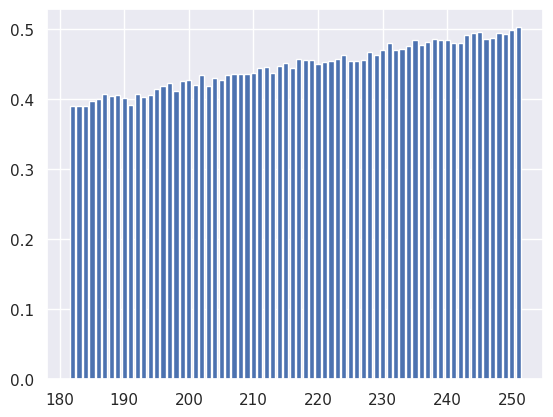

In [ ]:
# 1. Convertimos las llaves del diccionario a una lista para el eje X
plt.bar(list(dic_resultados.keys()), list(dic_resultados.values()))

# PROBLEMA 3: Ruleta infalible
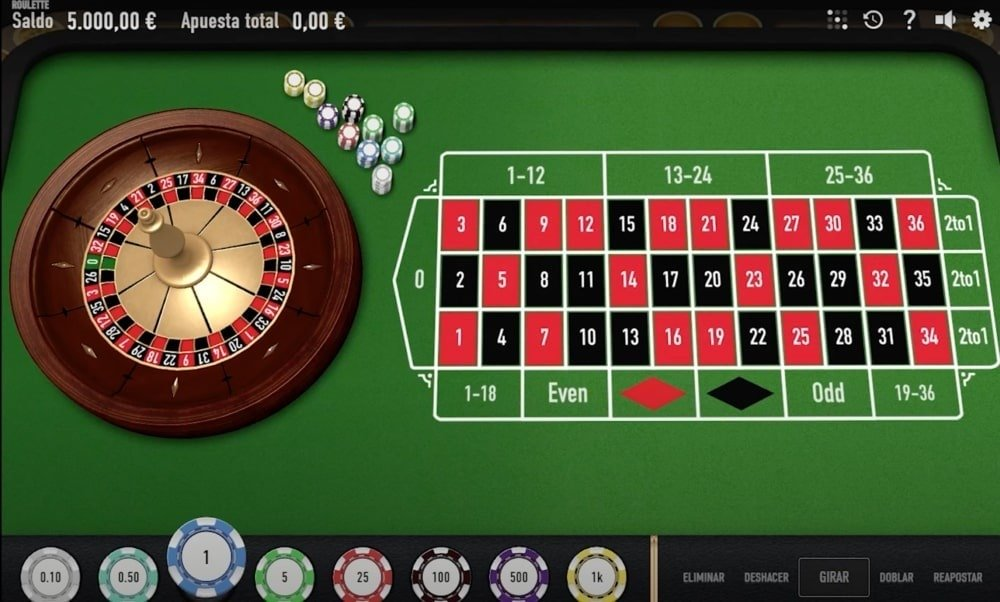



Hay un supuesto método para ganar siempre en la ruleta. Consiste en:


1.   Se apuesta siempre a una apuesta “simple” (rojo/negro, par/impar).

2.   Se empieza apostando una cantidad fija mínima b (por ejemplo, 1€).

3.	Si ganas:
- Obtienes un beneficio neto de +b (1€)
- Vuelves a apostar b

4.	Si pierdes:
- Doblas la apuesta en la siguiente ronda:
2b, 4b, 8b, ... hasta que ganes y recuperes todo lo perdido + 1€ de ganancia.

5.	El juego termina cuando:
- alcanzas un objetivo de beneficio, o
- no puedes cubrir la siguiente apuesta (quiebra)

In [ ]:
def ruleta(capital_inicial, objetivo_beneficio, apuesta_minima=1):
    capital_actual = capital_inicial
    apuesta_actual = apuesta_minima
    rondas_jugadas = 0
    beneficio_obtenido = 0
    capital_por_ronda = {"Ronda 0": capital_inicial}

    playing = True
    while playing:

        apuesta_ganadora = np.random.choice([True, False], p=[18/37, 19/37])
        if apuesta_ganadora:
            capital_actual = capital_actual + apuesta_actual
            apuesta_actual = apuesta_minima
        else:
            capital_actual = capital_actual - apuesta_actual
            apuesta_actual = apuesta_actual * 2

        rondas_jugadas += 1
        capital_por_ronda[f"Ronda {rondas_jugadas}"] = capital_actual
        if capital_actual >= capital_inicial+objetivo_beneficio:
            playing = False
        elif capital_actual <= 0:
            playing = False
        elif capital_actual < apuesta_actual:
            playing = False

    df = pd.DataFrame([capital_por_ronda])
    df.insert(0, "Final", capital_actual)
    df.insert(1, "Rondas", rondas_jugadas)
    return df

In [ ]:
ruleta(capital_inicial=100, objetivo_beneficio=50, apuesta_minima=1)

,Final,Rondas,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,...,Ronda 101,Ronda 102,Ronda 103,Ronda 104,Ronda 105,Ronda 106,Ronda 107,Ronda 108,Ronda 109,Ronda 110
0,150,110,100,101,102,101,103,104,103,101,...,142,146,145,143,147,148,147,149,148,150


### Reto 1 — Salir con +20€ empezando con 100€
Preguntas

	1.	¿Cuál es la probabilidad de conseguir los +20€ sin arruinarse?
	2.	¿Cuántas rondas suele durar el juego cuando se tiene éxito?
	3.	¿Cuál es el beneficio medio del casino?

In [ ]:
capital_inicial = 100
objetivo_beneficio = 20
apuesta_minima = 1
num_simulaciones = 10000

df_sim_1 = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: ruleta(capital_inicial, objetivo_beneficio, apuesta_minima)
)

df_sim_1

,Final,Rondas,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,...,Ronda 57,Ronda 58,Ronda 59,Ronda 60,Ronda 61,Ronda 62,Ronda 63,Ronda 64,Ronda 65,Ronda 66
0,49,29,100,99,97,101,102,103,102,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,48,31,100,101,100,98,102,101,99,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,120,31,100,99,97,101,102,103,102,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,120,43,100,99,97,93,85,69,101,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,120,36,100,101,100,98,94,102,103,104.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,120,43,100,99,97,93,101,100,98,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,120,43,100,99,101,100,102,101,103,104.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,56,37,100,101,102,101,103,104,103,101.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,120,39,100,101,102,101,103,102,104,103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


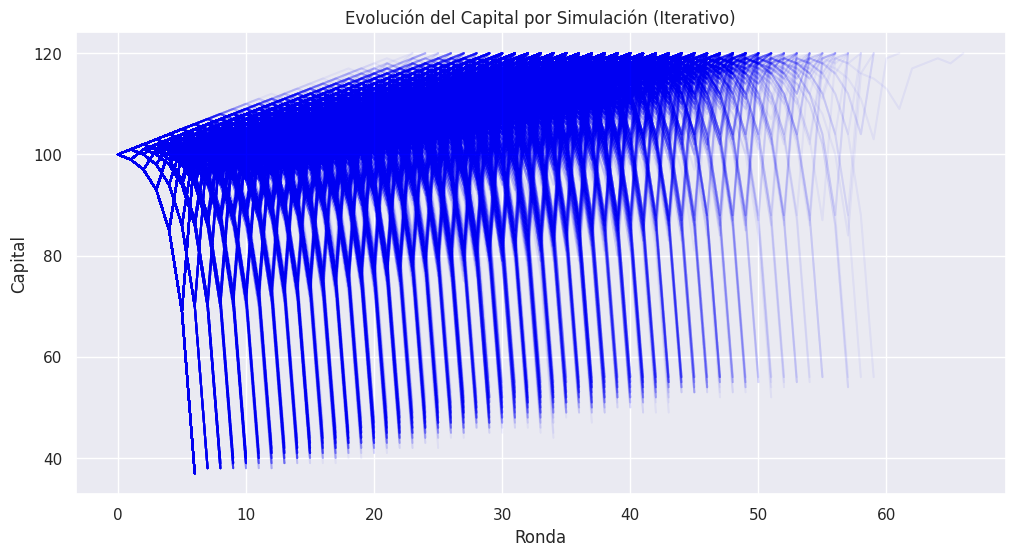

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Evolución del Capital por Simulación (Iterativo)')
plt.xlabel('Ronda')
plt.ylabel('Capital')

# Método 1: Usando un loop
for i in range(len(df_sim_1)):
    capital_evolution = df_sim_1.iloc[i, 2:].dropna().values
    plt.plot(capital_evolution, color='blue', alpha=0.05) # Alta transparencia para ver la densidad

plt.grid(True)
plt.show()

In [ ]:
# 1 ¿Cuál es la probabilidad de conseguir los +20€?
(df_sim_1["Final"]==120).mean()

np.float64(0.6913)

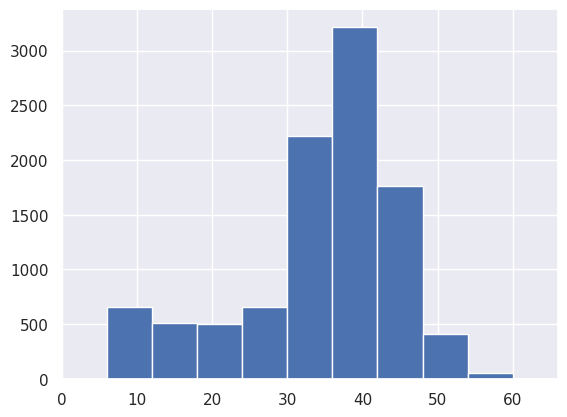

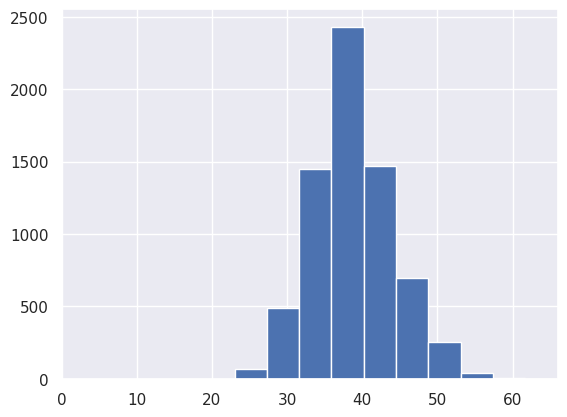

In [ ]:
# 2 ¿Cuántas rondas suele durar el juego cuando se tiene éxito?
plt.hist(df_sim_1["Rondas"])
plt.xlim(0,max(df_sim_1["Rondas"]))
plt.show()
plt.hist(df_sim_1.loc[df_sim_1["Final"]==120,"Rondas"])
plt.xlim(0,max(df_sim_1["Rondas"]))
plt.show()

In [ ]:
display(df_sim_1["Rondas"].describe())
display(df_sim_1.loc[df_sim_1["Final"]==120,"Rondas"].describe())

,Rondas
count,10000.000000
mean,33.868300
std,10.759253
min,6.000000
25%,30.000000
50%,36.000000
75%,41.000000
max,66.000000


,Rondas
count,6913.000000
mean,38.719514
std,5.401972
min,23.000000
25%,35.000000
50%,38.000000
75%,42.000000
max,66.000000


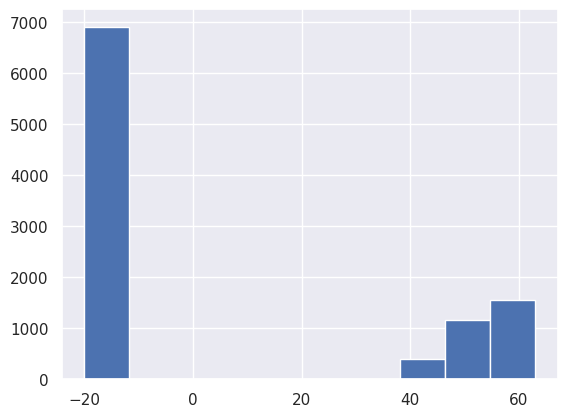

,Final
count,10000.000000
mean,2.908500
std,34.433587
min,-20.000000
25%,-20.000000
50%,-20.000000
75%,48.000000
max,63.000000


In [ ]:
# 3 ¿Cuál es el beneficio medio del casino?
beneficio_casino = 100 - df_sim_1["Final"]
plt.hist(beneficio_casino)
plt.show()
beneficio_casino.describe()

### Reto 2 — Salir cuando doblas el capital (100€ → 200€)

Preguntas

	1.	¿Es mucho menor la probabilidad de éxito que en el reto anterior?
	2.	¿Crece lineal o exponencialmente el riesgo?
	3.	¿Cuál es el beneficio medio del casino?

In [ ]:
capital_inicial = 100
objetivo_beneficio = 100
apuesta_minima = 1
num_simulaciones = 10000

df_sim_2 = escenario_simulacion(
    num_simulaciones=num_simulaciones,
    funcion_sim=lambda: ruleta(capital_inicial, objetivo_beneficio, apuesta_minima)
)

df_sim_2

,Final,Rondas,Ronda 0,Ronda 1,Ronda 2,Ronda 3,Ronda 4,Ronda 5,Ronda 6,Ronda 7,...,Ronda 240,Ronda 241,Ronda 242,Ronda 243,Ronda 244,Ronda 245,Ronda 246,Ronda 247,Ronda 248,Ronda 249
0,49,169,100,99,101,102,101,103,102,104.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200,182,100,99,101,100,98,94,86,70.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13,90,100,99,101,100,98,102,103,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24,122,100,99,97,101,100,102,103,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,60,166,100,99,97,93,85,69,101,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,61,167,100,99,101,100,98,102,101,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,60,55,100,99,97,101,102,103,104,105.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,200,189,100,101,100,98,94,86,70,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,53,32,100,101,100,102,103,102,104,103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


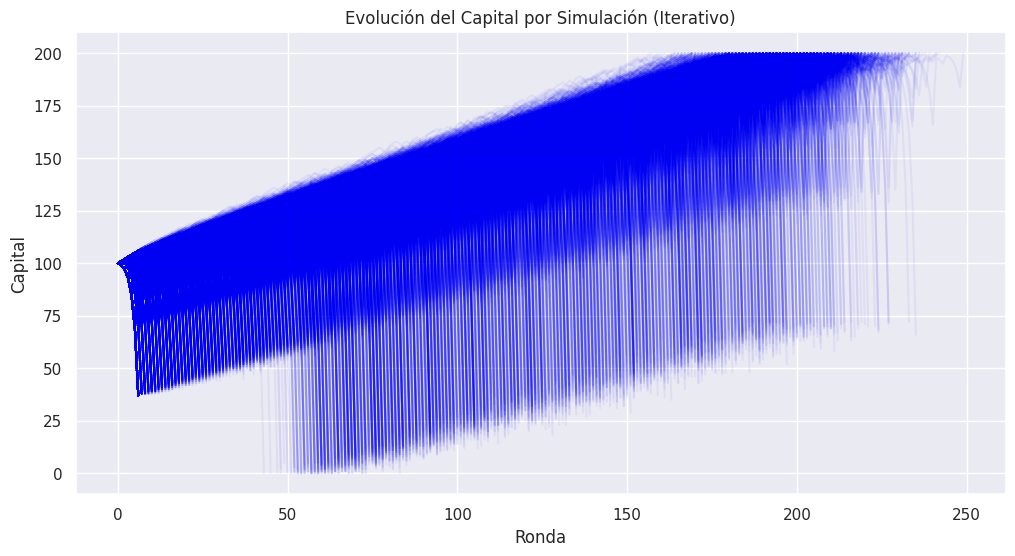

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Evolución del Capital por Simulación (Iterativo)')
plt.xlabel('Ronda')
plt.ylabel('Capital')

# Método 1: Usando un loop
for i in range(len(df_sim_2)):
    capital_evolution = df_sim_2.iloc[i, 2:].dropna().values
    plt.plot(capital_evolution, color='blue', alpha=0.05) # Alta transparencia para ver la densidad

plt.grid(True)
plt.show()

In [ ]:
# 1 ¿Es mucho menor la probabilidad de éxito que en el reto anterior?
print((df_sim_1["Final"]==120).mean())
print((df_sim_2["Final"]==200).mean())

0.6913
0.2977


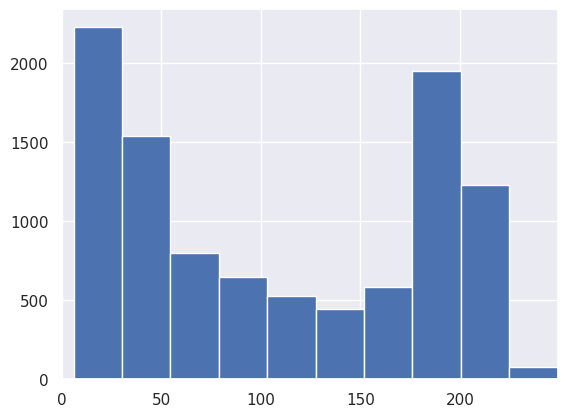

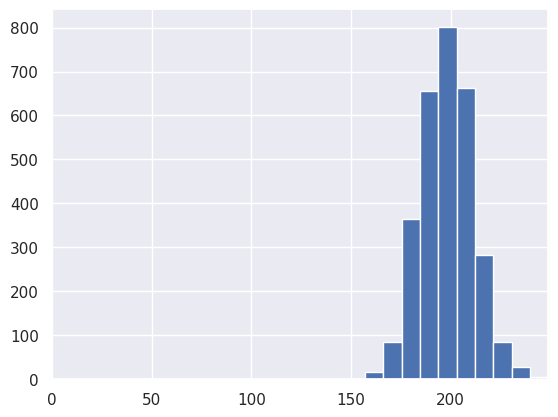

In [ ]:
# 2 ¿Crece lineal o exponencialmente el riesgo?
plt.hist(df_sim_2["Rondas"])
plt.xlim(0,max(df_sim_2["Rondas"]))
plt.show()
plt.hist(df_sim_2.loc[df_sim_2["Final"]==200,"Rondas"])
plt.xlim(0,max(df_sim_2["Rondas"]))
plt.show()

In [ ]:
display(df_sim_2["Rondas"].describe())
display(df_sim_2.loc[df_sim_2["Final"]==200,"Rondas"].describe())

,Rondas
count,10000.000000
mean,107.462700
std,75.147774
min,6.000000
25%,35.000000
50%,95.000000
75%,188.000000
max,249.000000


,Rondas
count,2977.000000
mean,197.812563
std,12.905381
min,157.000000
25%,189.000000
50%,197.000000
75%,206.000000
max,249.000000


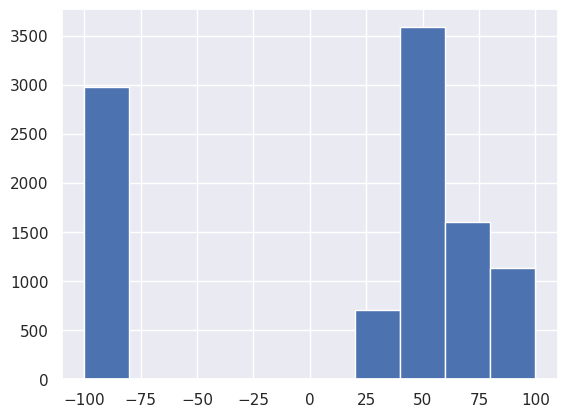

,Final
count,10000.000000
mean,11.548100
std,74.060323
min,-100.000000
25%,-100.000000
50%,48.000000
75%,61.000000
max,100.000000


In [ ]:
# 3 ¿Cuál es el beneficio medio del casino?
beneficio_casino = 100 - df_sim_2["Final"]
plt.hist(beneficio_casino)
plt.show()
beneficio_casino.describe()